In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("House Price Prediction Dataset.csv")

In [3]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
df.shape

(2000, 10)

In [5]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 184.3 KB


In [7]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [10]:
df["Price"].describe()

count      2000.000000
mean     537676.855000
std      276428.845719
min       50005.000000
25%      300098.000000
50%      539254.000000
75%      780086.000000
max      999656.000000
Name: Price, dtype: float64

In [12]:
print("Minimum Price: ",df["Price"].min())
print("Maximum Price: ",df["Price"].max())
print("Average Price: ",df["Price"].mean())
print("Median Price: ",df["Price"].median())

Minimum Price:  50005
Maximum Price:  999656
Average Price:  537676.855
Median Price:  539254.0


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

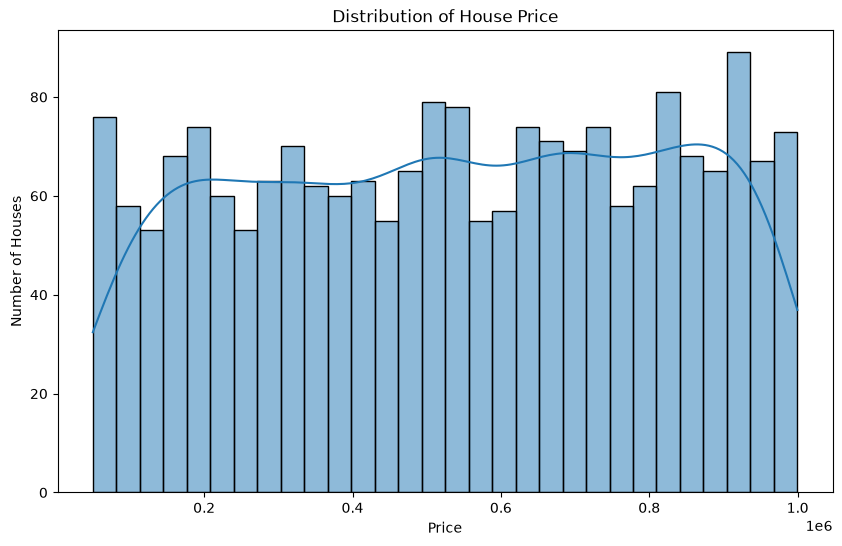

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(df['Price'],bins=30,kde=True)
plt.title("Distribution of House Price")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.show()

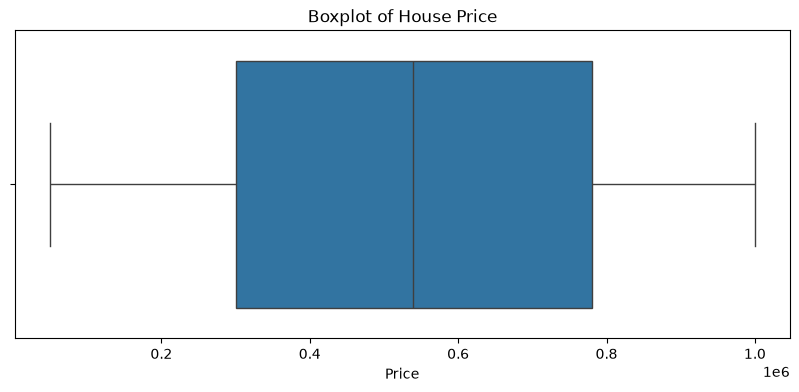

In [19]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['Price'])
plt.title("Boxplot of House Price")
plt.xlabel("Price")
plt.show()

## Feature Selection

The target variable for this project is **Price**, which represents the
selling price of the house.

The following features were selected as predictors:

- **Area:** Larger houses may have higher prices because they provide more living space.
- **Bedrooms:** The number of bedrooms provides information about the size and capacity of the house.
- **Bathrooms:** Houses with more bathrooms may have different price values.
- **Floors:** The number of floors represents the structure and size of the property.
- **YearBuilt:** The construction year can indicate the age of the house, which may influence its price.
- **Location:** Location can influence property prices because houses in different locations may have different market values.
- **Condition:** The condition of a house can affect its selling price.
- **Garage:** Garage availability is a property feature that may contribute to the house price.

The **Id** column is excluded because it is only an identifier and does not represent a meaningful characteristic of the house.

In [20]:
numeric_features=[
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt"
]


In [24]:
categorical_features=[
    "Location",
    "Condition",
    "Garage"
]
target="Price"
x=df[numeric_features+categorical_features]
y=df[target]


In [28]:
print("X shape:", x.shape)
print("y shape:", y.shape)

X shape: (2000, 8)
y shape: (2000,)


In [32]:
x.head()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage
0,1360,5,4,3,1970,Downtown,Excellent,No
1,4272,5,4,3,1958,Downtown,Excellent,No
2,3592,2,2,3,1938,Downtown,Good,No
3,966,4,2,2,1902,Suburban,Fair,Yes
4,4926,1,4,2,1975,Downtown,Fair,Yes


In [31]:
y.head()

0    149919
1    424998
2    266746
3    244020
4    636056
Name: Price, dtype: int64

In [34]:
x.isnull().sum()

Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
dtype: int64

In [35]:
y.isnull().sum()

np.int64(0)

In [36]:
df.duplicated().sum()

np.int64(0)

In [37]:
for column in categorical_features:
    print(column, ":", df[column].unique())

Location : <ArrowStringArray>
['Downtown', 'Suburban', 'Urban', 'Rural']
Length: 4, dtype: str
Condition : <ArrowStringArray>
['Excellent', 'Good', 'Fair', 'Poor']
Length: 4, dtype: str
Garage : <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough"
)

In [41]:
X_encoded = preprocessor.fit_transform(x)

In [42]:
print("Original number of features:", x.shape[1])
print("Encoded number of features:", X_encoded.shape[1])

Original number of features: 8
Encoded number of features: 15


In [43]:
correlation_data = df[
    ["Area", "Bedrooms", "Bathrooms", "Floors", "YearBuilt", "Price"]
]

correlation_matrix = correlation_data.corr()

correlation_matrix

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
Area,1.000000,0.047523,0.021881,0.017749,-0.011609,0.001542
Bedrooms,0.047523,1.000000,-0.011990,0.010435,-0.014125,-0.003471
Bathrooms,0.021881,-0.011990,1.000000,0.029089,-0.000839,-0.015737
Floors,0.017749,0.010435,0.029089,1.000000,-0.006474,0.055890
YearBuilt,-0.011609,-0.014125,-0.000839,-0.006474,1.000000,0.004845
Price,0.001542,-0.003471,-0.015737,0.055890,0.004845,1.000000


plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of House Price Features")
plt.show()

In [45]:
price_correlation = correlation_matrix["Price"].sort_values(ascending=False)

price_correlation

Price        1.000000
Floors       0.055890
YearBuilt    0.004845
Area         0.001542
Bedrooms    -0.003471
Bathrooms   -0.015737
Name: Price, dtype: float64

### Correlation Analysis

The correlation heatmap shows the linear relationship between the numerical
features and house price.

In this dataset, the numerical features have very weak linear correlations
with Price. Floors has the highest positive correlation with Price (0.055890),
while Bathrooms has the lowest correlation (-0.015737).

These results indicate that the numerical features alone do not show a strong
linear relationship with house price. The categorical features such as
Location, Condition, and Garage will also be included in the model after
One-Hot Encoding.

In [47]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

In [50]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1600, 8)
Testing features: (400, 8)
Training target: (1600,)
Testing target: (400,)


In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

In [52]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [53]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Area','Bedrooms','Bathrooms',...,'Location','Condition','Garage']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated 

In [54]:
y_pred = model.predict(X_test)

In [55]:
print("Actual prices:")
print(y_test.head(10).values)

print("\nPredicted prices:")
print(y_pred[:10])

Actual prices:
[514764 694256  66375 650243 223285 468127 513002 911525 723265 339416]

Predicted prices:
[521988.22189839 549119.31196651 487101.22235594 539752.7439933
 553242.24872512 521375.92025826 523320.18080583 578133.64353335
 545899.64738458 577368.69940644]


In [56]:
from sklearn.metrics import mean_squared_error, r2_score

In [60]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)

Mean Squared Error (MSE): 78321466146.0328


In [61]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 279859.72583784326


In [62]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: -0.006717808430749761


In [63]:
print("Model Evaluation")
print("-----------------")
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation
-----------------
MSE : 78321466146.0328
RMSE: 279859.72583784326
R²  : -0.006717808430749761


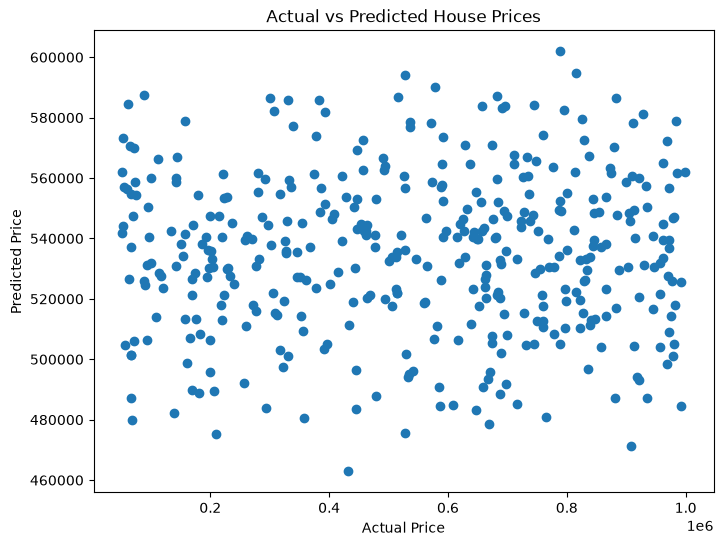

In [64]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

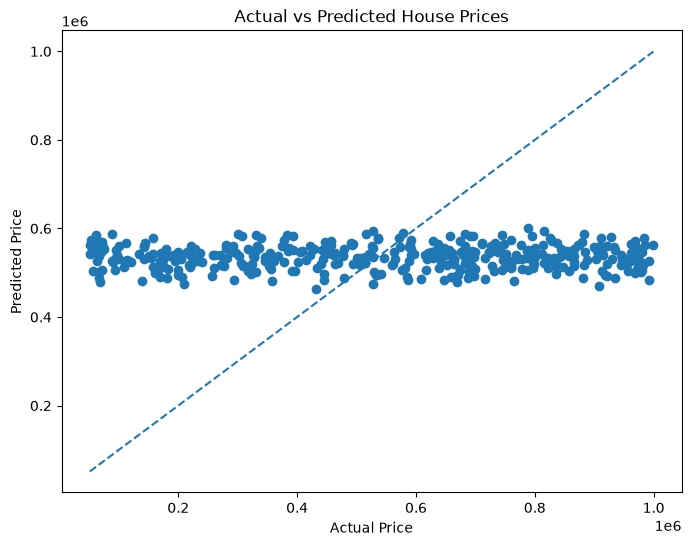

In [65]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [66]:
residuals = y_test - y_pred

print(residuals.head(10))

1860     -7224.221898
353     145136.688033
1333   -420726.222356
905     110490.256007
1289   -329957.248725
1273    -53248.920258
938     -10318.180806
1731    333391.356467
65      177365.352615
1323   -237952.699406
Name: Price, dtype: float64


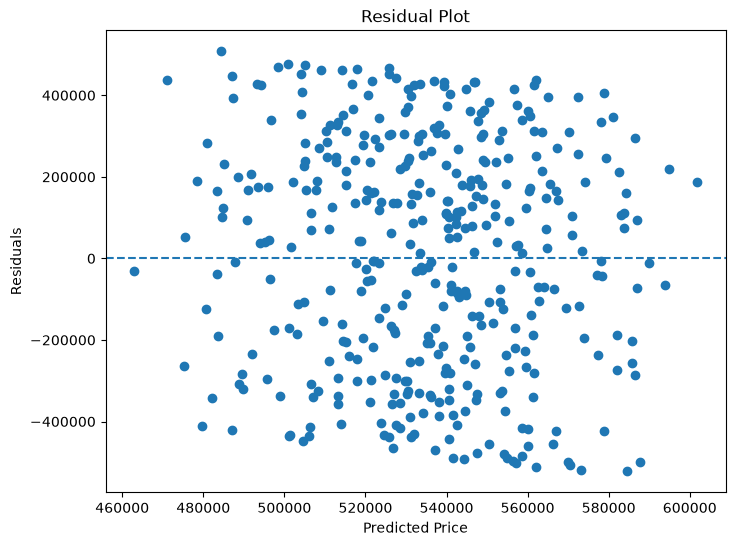

In [67]:
plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [69]:
print("Mean Residual:", residuals.mean())
print("Residual Standard Deviation:", residuals.std())

Mean Residual: 8623.215367676856
Residual Standard Deviation: 280077.15783084126


In [70]:
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

print(feature_names)

['cat__Location_Downtown' 'cat__Location_Rural' 'cat__Location_Suburban'
 'cat__Location_Urban' 'cat__Condition_Excellent' 'cat__Condition_Fair'
 'cat__Condition_Good' 'cat__Condition_Poor' 'cat__Garage_No'
 'cat__Garage_Yes' 'remainder__Area' 'remainder__Bedrooms'
 'remainder__Bathrooms' 'remainder__Floors' 'remainder__YearBuilt']


In [71]:
coefficients = model.named_steps["regressor"].coef_

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coefficient_df

,Feature,Coefficient
0,cat__Location_Downtown,-27.653231
1,cat__Location_Rural,1289.888789
2,cat__Location_Suburban,11484.336584
3,cat__Location_Urban,-12746.572142
4,cat__Condition_Excellent,-3803.882985
5,cat__Condition_Fair,20279.424861
6,cat__Condition_Good,-16744.927821
7,cat__Condition_Poor,269.385945
8,cat__Garage_No,-1186.765289
9,cat__Garage_Yes,1186.765289


In [72]:
positive_coefficients = coefficient_df.sort_values(
    by="Coefficient",
    ascending=False
)

positive_coefficients.head(10)

,Feature,Coefficient
13,remainder__Floors,23727.983633
5,cat__Condition_Fair,20279.424861
2,cat__Location_Suburban,11484.336584
1,cat__Location_Rural,1289.888789
9,cat__Garage_Yes,1186.765289
7,cat__Condition_Poor,269.385945
14,remainder__YearBuilt,117.613885
11,remainder__Bedrooms,76.784827
10,remainder__Area,-0.575754
0,cat__Location_Downtown,-27.653231


In [73]:
negative_coefficients = coefficient_df.sort_values(
    by="Coefficient",
    ascending=True
)

negative_coefficients.head(10)

,Feature,Coefficient
6,cat__Condition_Good,-16744.927821
3,cat__Location_Urban,-12746.572142
12,remainder__Bathrooms,-9662.248234
4,cat__Condition_Excellent,-3803.882985
8,cat__Garage_No,-1186.765289
0,cat__Location_Downtown,-27.653231
10,remainder__Area,-0.575754
11,remainder__Bedrooms,76.784827
14,remainder__YearBuilt,117.613885
7,cat__Condition_Poor,269.385945


In [74]:
coefficient_df

,Feature,Coefficient
0,cat__Location_Downtown,-27.653231
1,cat__Location_Rural,1289.888789
2,cat__Location_Suburban,11484.336584
3,cat__Location_Urban,-12746.572142
4,cat__Condition_Excellent,-3803.882985
5,cat__Condition_Fair,20279.424861
6,cat__Condition_Good,-16744.927821
7,cat__Condition_Poor,269.385945
8,cat__Garage_No,-1186.765289
9,cat__Garage_Yes,1186.765289


## Coefficient Analysis

The Linear Regression coefficients show how each feature is associated with
the predicted house price while holding the other model features constant.

Among the numerical features, **Floors** has the largest positive coefficient
(23,727.98), while **Bathrooms** has a negative coefficient (-9,662.25).

Among the encoded categorical features, **Condition_Fair** has a positive
coefficient of 20,279.42, while **Condition_Good** has a negative coefficient
of -16,744.93.

The categorical coefficients should be interpreted relative to the omitted
reference categories created during One-Hot Encoding.

Overall, the coefficient results should be interpreted cautiously because the
model achieved an R² score of approximately -0.067, indicating that the
linear model does not explain the variation in house prices well for this
dataset.

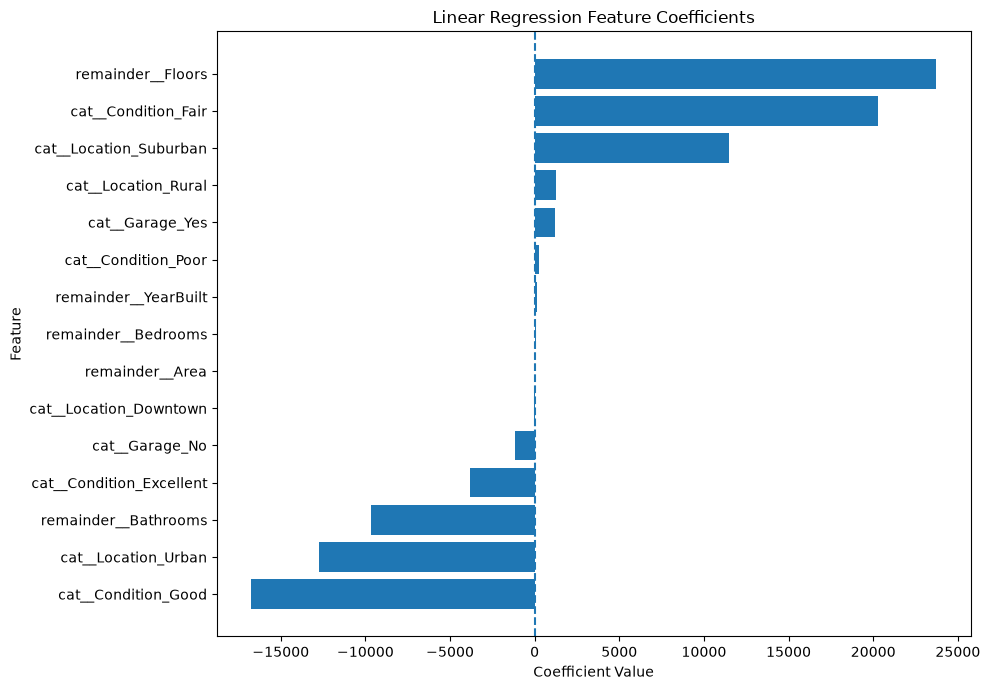

In [75]:
coefficient_plot = coefficient_df.sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 7))

plt.barh(
    coefficient_plot["Feature"],
    coefficient_plot["Coefficient"]
)

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Linear Regression Feature Coefficients")

plt.axvline(x=0, linestyle="--")

plt.tight_layout()
plt.show()

## Key Findings

1. The dataset contains 2,000 house records and 10 columns.

2. The dataset did not contain missing values in the available columns.

3. The numerical features showed very weak linear correlations with house price.
   Floors had the highest positive correlation with Price (0.055890), while
   Bathrooms had the lowest correlation (-0.015737).

4. Location, Condition, and Garage were categorical variables and were
   converted into numerical features using One-Hot Encoding.

5. The dataset was divided into 80% training data and 20% testing data.

6. A Linear Regression model was trained using the selected numerical and
   categorical features.

7. The model produced:
   - MSE: 78,321,466,146.0328
   - RMSE: 279,859.7258
   - R²: -0.067178

8. The negative R² indicates that the Linear Regression model did not explain
   the variation in house prices effectively for this dataset.

9. In the fitted model, Floors had the largest positive numerical coefficient,
   while Bathrooms had a negative coefficient. Among the categorical features,
   Condition_Fair had the largest positive coefficient and Condition_Good had
   a negative coefficient.

10. The coefficient values should be interpreted cautiously because the
    overall model performance was weak.

## Conclusion

In this project, a Linear Regression model was developed to predict house
prices using numerical and categorical property features.

The dataset was cleaned and explored using pandas, and categorical variables
were converted using One-Hot Encoding. A correlation heatmap was used to
investigate relationships between numerical features and house price.

The data was divided into training and testing sets using an 80/20 split.
The Linear Regression model was then trained and evaluated using MSE, RMSE,
and R².

The model achieved an R² score of approximately -0.067, indicating that the
selected linear model did not perform well on the test data. The weak
correlations observed during EDA are also consistent with the limited
predictive performance.

The project demonstrates the complete workflow of data loading, exploratory
data analysis, preprocessing, feature encoding, model training, evaluation,
visualization, residual analysis, and coefficient interpretation.